### EEG Signal Exploration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mne
from sklearn.cluster import KMeans
print("Finished importing libraries")

Finished importing libraries


In [3]:
# Load the dataset
raw = mne.io.read_raw_brainvision(
   "sub-00063_ses-2_task-sleep_acq-20170223T0434.vhdr",
    preload=True
)

Extracting parameters from sub-00063_ses-2_task-sleep_acq-20170223T0434.vhdr...
Setting channel info structure...


C:\Users\hp\AppData\Local\Temp\ipykernel_9452\3842733681.py:2: RuntimeWarning: No coordinate information found for channels ['ECG', 'EMG']. Setting channel types to misc. To avoid this warning, set channel types explicitly.
  raw = mne.io.read_raw_brainvision(


Reading 0 ... 1934429  =      0.000 ...  7737.716 secs...


C:\Users\hp\AppData\Local\Temp\ipykernel_9452\3842733681.py:2: RuntimeWarning: Not setting positions of 2 misc channels found in montage:
['ECG', 'EMG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_brainvision(


In [14]:
print("Sampling rate", raw.info['sfreq'])        # sampling rate (how many readings per second)
print("Total number of samples", len(raw.times))           # total number of samples
print("Total duration", raw.times[-1], 'seconds') # total duration
seconds = raw.times[-1]
# Get hours and remaining seconds
hours, remainder = divmod(seconds, 3600)
# Get minutes and final seconds
minutes, seconds = divmod(remainder, 60)

print(f"Total Duration:{int(hours)} hours, {int(minutes)} minutes, {seconds:.2f} seconds")

Sampling rate 250.0
Total number of samples 1934430
Total duration 7737.716 seconds
Total Duration:2 hours, 8 minutes, 57.72 seconds


#### Visualizing the data

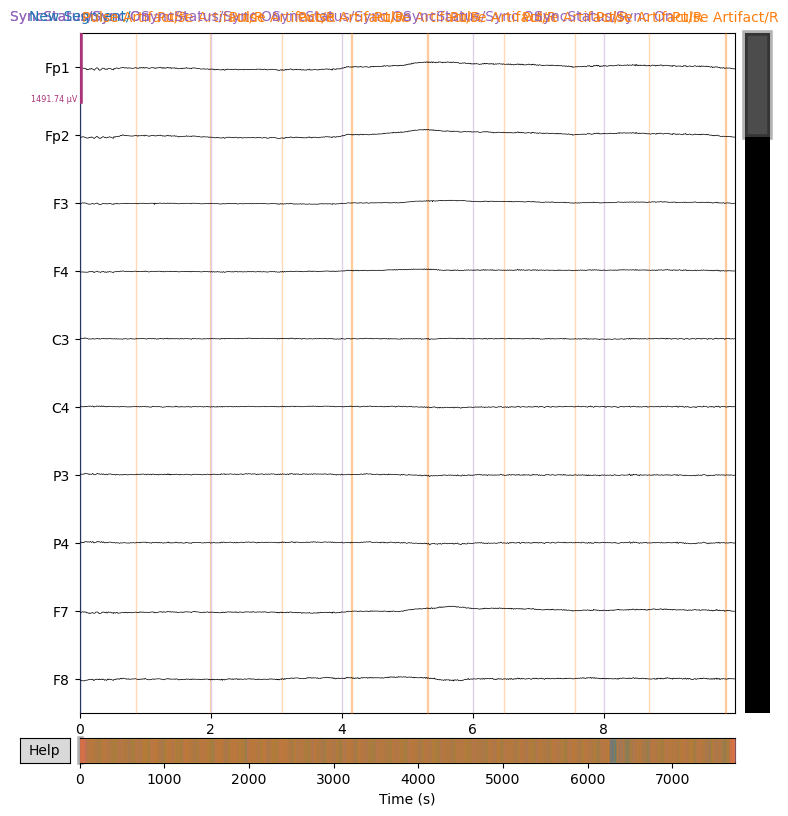

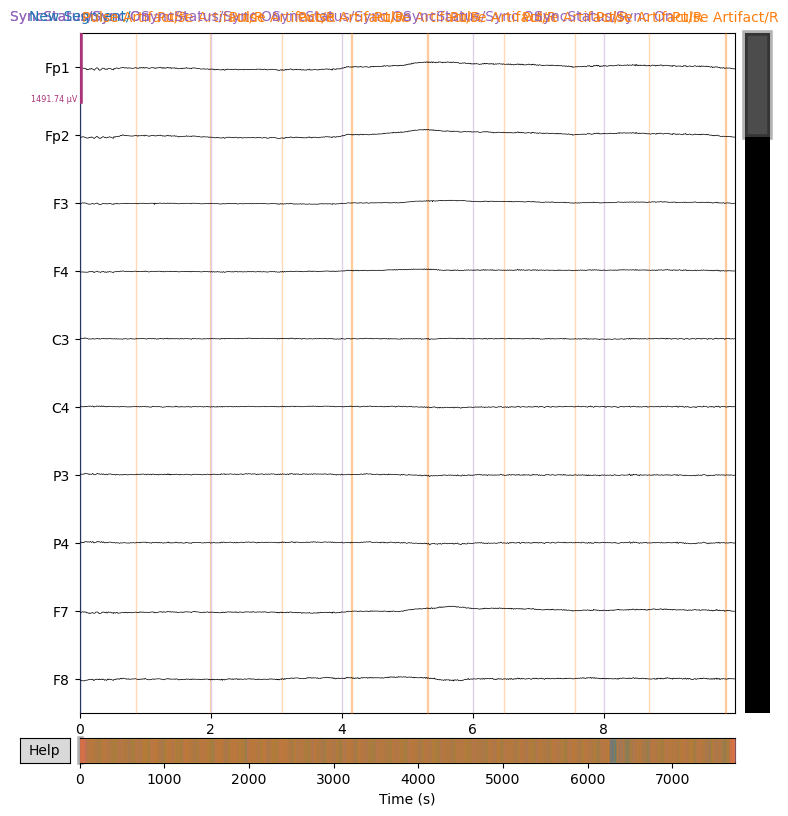

In [16]:
raw.plot(n_channels=10, duration=10, scalings='auto')

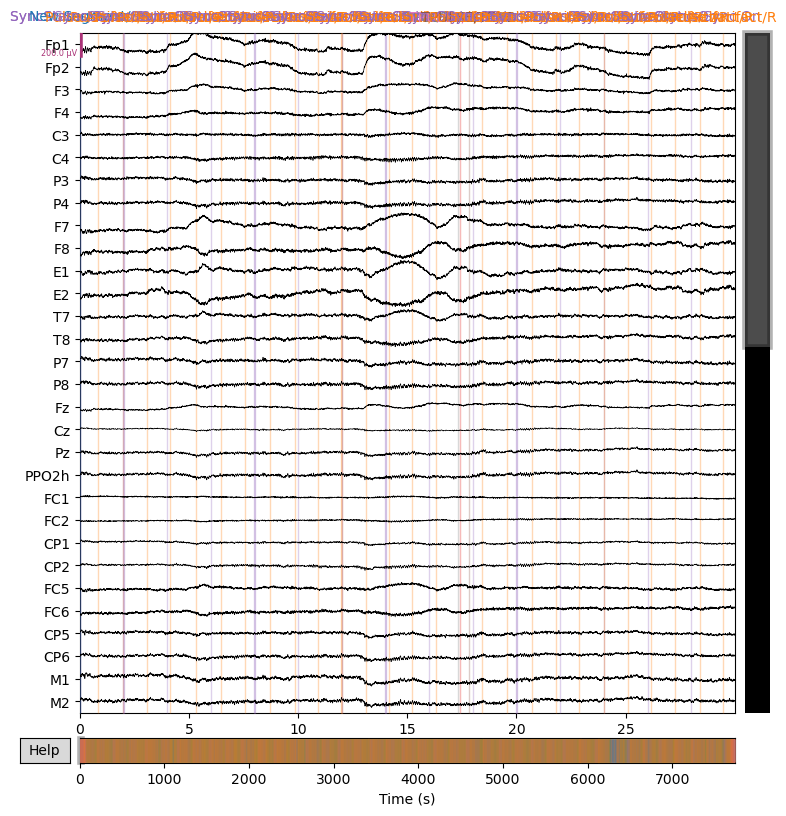

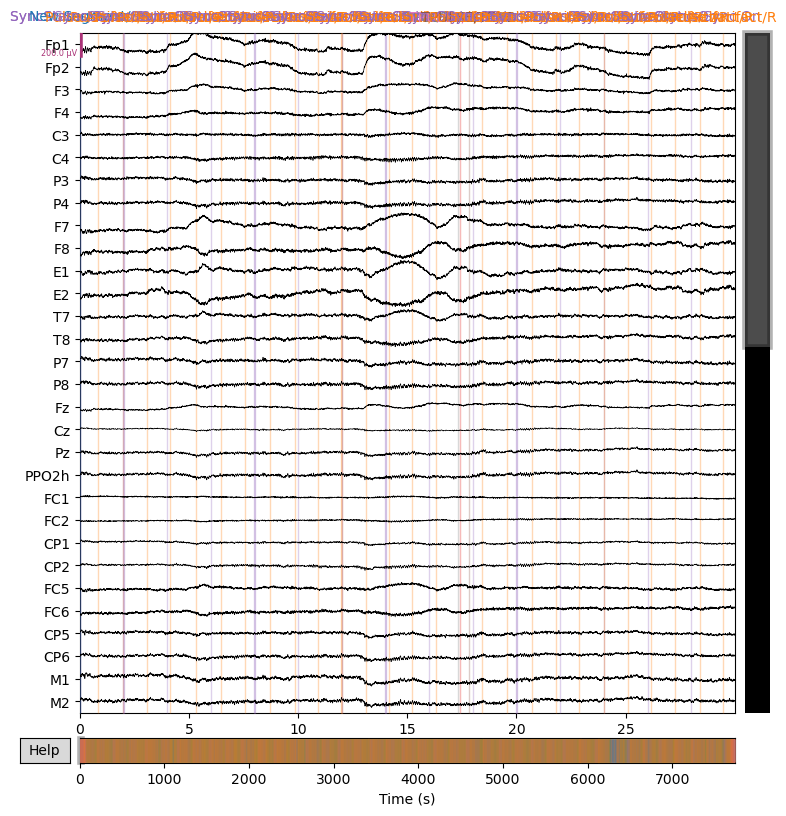

In [17]:
raw.plot(n_channels=30, duration=30, scalings=dict(eeg=100e-6))

In [18]:
raw.notch_filter(freqs=50) # this removes electrical interference, the  average in most countries is 50

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1651 samples (6.604 s)



<RawBrainVision | sub-00063_ses-2_task-sleep_acq-20170223T0434_eeg.eeg, 65 x 1934430 (7737.7 s), ~959.4 MiB, data loaded>

In [19]:
raw.filter(l_freq= 0.5, h_freq= 40) # this removes anything lower than 0.5 and higher than 40 from the data because sleep data is mostly withinn there

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (6.604 s)



<RawBrainVision | sub-00063_ses-2_task-sleep_acq-20170223T0434_eeg.eeg, 65 x 1934430 (7737.7 s), ~959.4 MiB, data loaded>

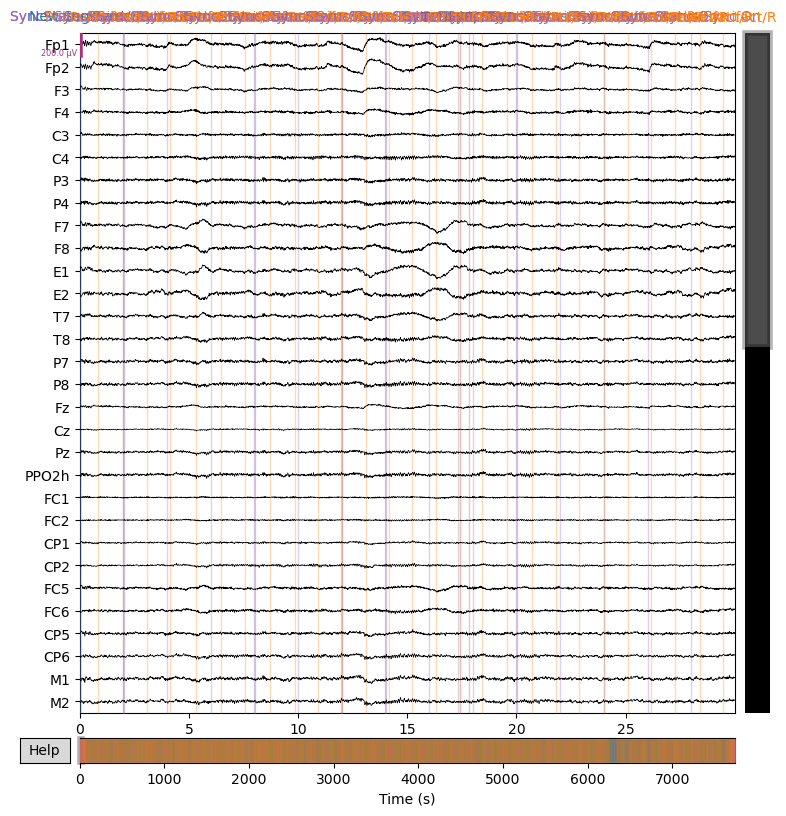

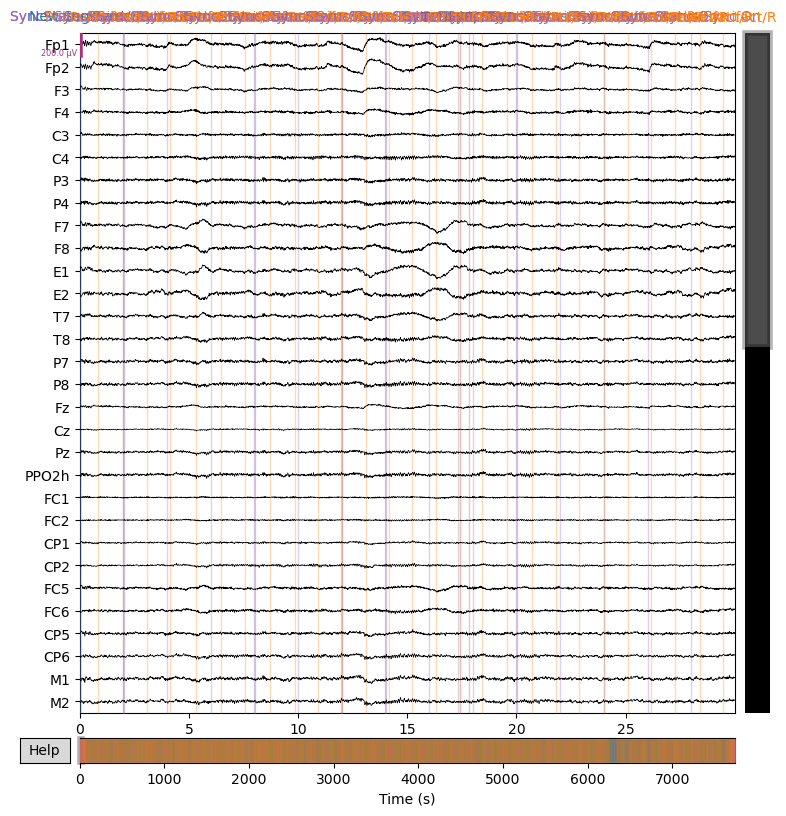

In [20]:
raw.plot(n_channels=30, duration=30, scalings=dict(eeg=100e-6))

In [21]:
raw.info['bads'] = ['Cz', 'FC1', 'FC2', 'CP1']  # ignoring the bad channels that dont just fit
print(raw.ch_names)

['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'F7', 'F8', 'E1', 'E2', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz', 'PPO2h', 'FC1', 'FC2', 'CP1', 'CP2', 'FC5', 'FC6', 'CP5', 'CP6', 'M1', 'M2', 'POz', 'ECG', 'F1', 'F2', 'C1', 'C2', 'P1', 'P2', 'AF3', 'AF4', 'FC3', 'FC4', 'CP3', 'CP4', 'PO3', 'PO4', 'F5', 'F6', 'C5', 'C6', 'P5', 'P6', 'AF7', 'AF8', 'FT7', 'FT8', 'TP7', 'TP8', 'PO7', 'PO8', 'FT9', 'FT10', 'Fpz', 'CPz', 'EMG']


In [22]:
raw_copy = raw
from mne.preprocessing import ICA

ica = ICA(n_components=25, random_state=42)
ica.fit(raw_copy)

Fitting ICA to data using 59 channels (please be patient, this may take a while)
Selecting by number: 25 components
Fitting ICA took 317.1s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,48 iterations on raw data (1934430 samples)
ICA components,25
Available PCA components,59
Channel types,eeg
ICA components marked for exclusion,—


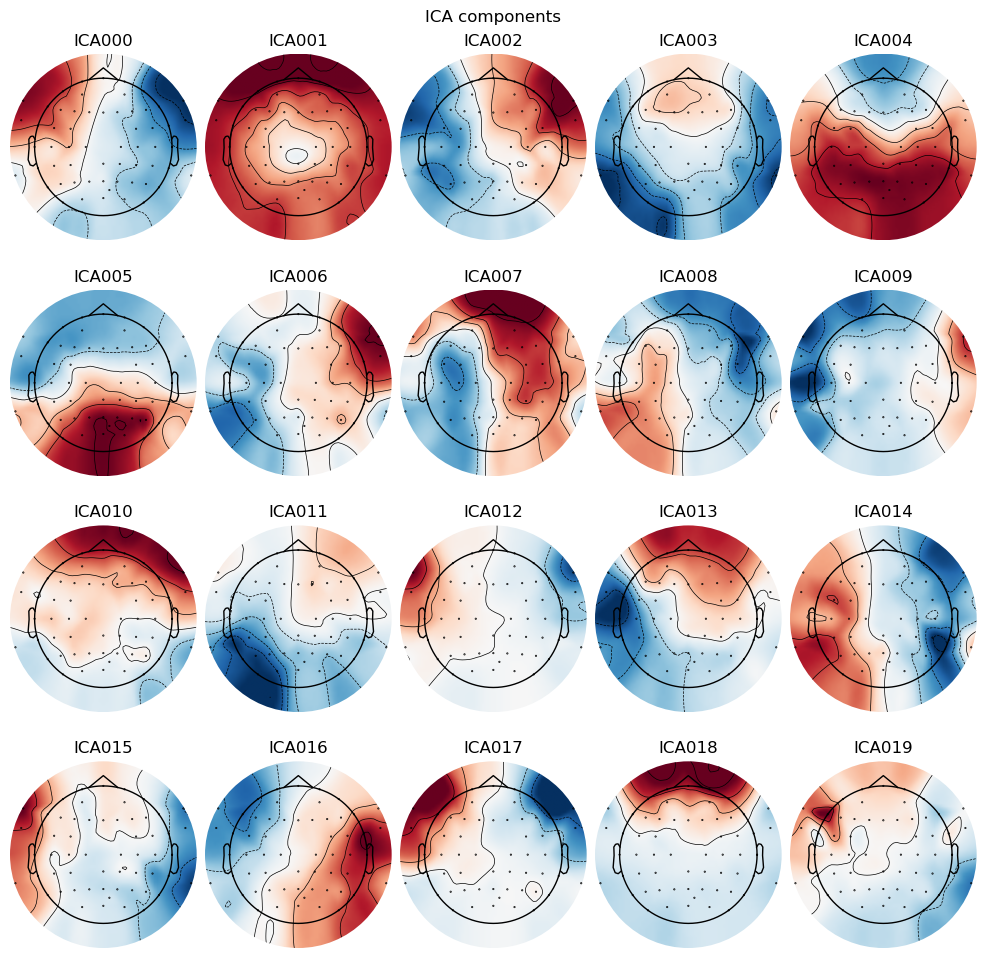

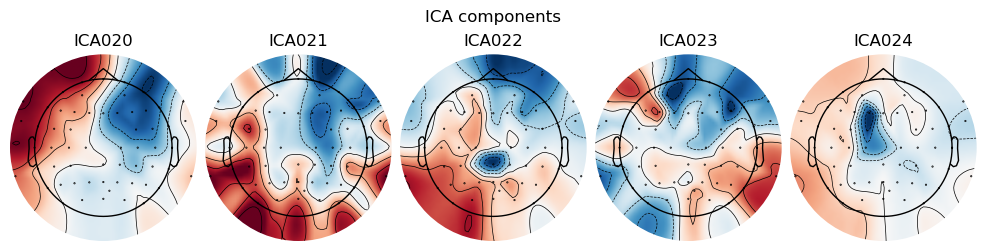

[<MNEFigure size 975x967 with 20 Axes>, <MNEFigure size 975x260.5 with 5 Axes>]

In [23]:
ica.plot_components()

#### So in our data there are eye blnks and head tilts which are not actual brain activity but got picked up by the eeg, this ica function shows us and we remove it from the preprocessing

In [26]:
ica.exclude = [0,1,4]
raw_clean = ica.apply(raw_copy.copy())

Applying ICA to Raw instance
    Transforming to ICA space (25 components)
    Zeroing out 3 ICA components
    Projecting back using 59 PCA components


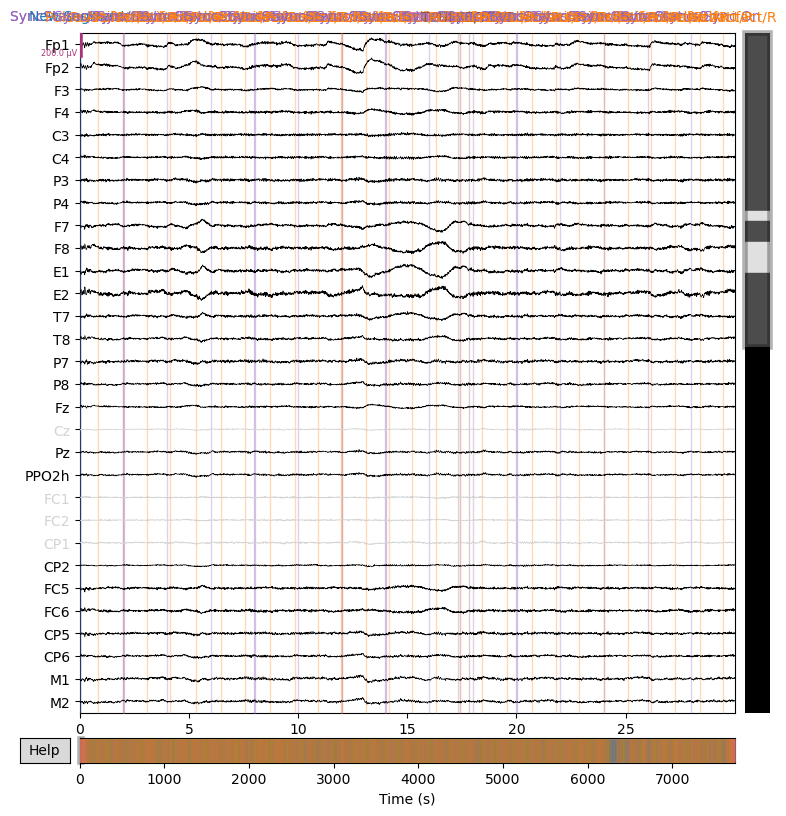

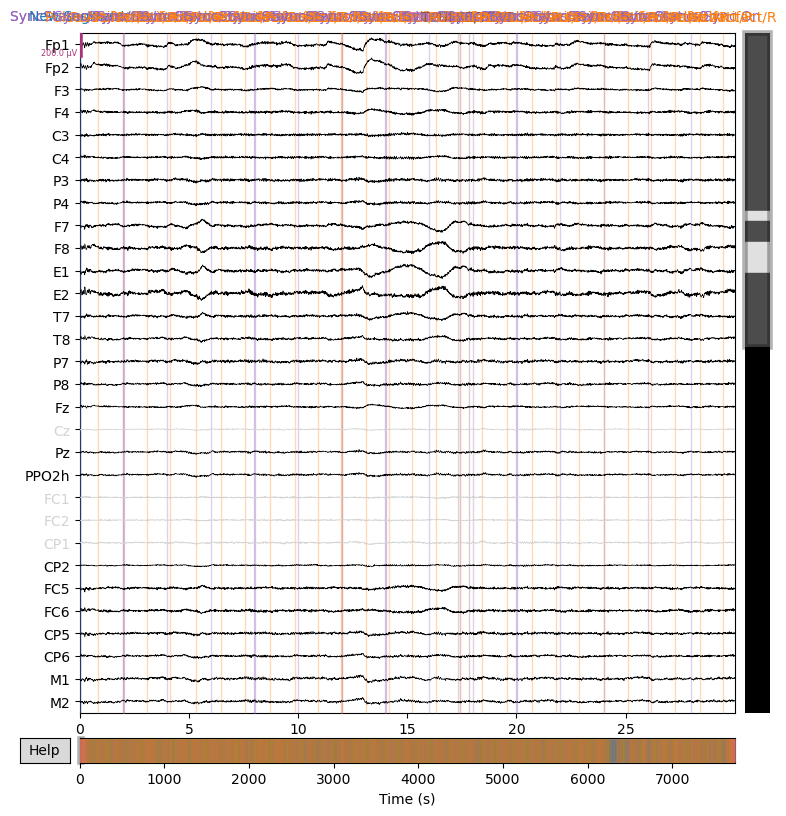

In [27]:
raw_clean.plot(n_channels=30, duration=30, scalings=dict(eeg=100e-6))